In [1]:
import pandas as pd
from math import exp
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
import multiprocessing
from sklearn.cluster import MeanShift
import random

In [2]:
from models_FTS.components import parafins, olefins, others

In [3]:
from y_n import y_n
from upsilon_n import upsilon_n

In [4]:
def upsilons(N, T):
    return {n: upsilon_n(n, T) for n in N}

In [5]:
np.random.seed(84)
random.seed(84)

In [6]:
# pd.set_option('display.float_format', '{:,.4E}'.format)

In [7]:
pd.options.display.max_seq_items = 2000

In [8]:
reconciled_data = pd.read_pickle('reconciled_data.pkl')

In [9]:
kinetic_data = reconciled_data.loc[reconciled_data.CINÉTICA == True]

In [10]:
X = kinetic_data[['T_R_C']]
clustering = MeanShift(bandwidth=2).fit(X)

array([2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 1, 1, 1,
       1, 1, 3, 3, 2, 2, 2, 0, 0, 0, 0, 3, 3, 0, 0, 0, 2, 2, 2, 3, 3, 3,
       2, 2, 2, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4])

In [11]:
kinetic_data['cluster'] = clustering.labels_

In [12]:
cluster_set = list(set(kinetic_data.cluster))

In [13]:
val_clusters = random.sample(cluster_set, 2)

[5, 2]

In [14]:
kinetic_data.groupby(['cluster'])['T_R_C'].mean().sort_values()

cluster
3    211.000000
0    222.000000
2    233.000000
1    243.687500
5    253.500000
4    262.545455
Name: T_R_C, dtype: float64

In [15]:
kinetic_data.groupby(['cluster'])['T_R_C'].std()

cluster
0    0.000000
1    0.478714
2    0.000000
3    0.000000
4    0.522233
5    0.527046
Name: T_R_C, dtype: float64

In [16]:
kinetic_data['cluster'].isin(val_clusters).sum() / len(kinetic_data)

np.float64(0.3023255813953488)

In [17]:
Fj_out = kinetic_data[[
    'F_H2_s_mol_s', 'F_CH4_s_mol_s', 'F_CO_s_mol_s',
       'F_CO2_s_mol_s', 'F_C2H4_s_mol_s', 'F_C2H6_s_mol_s', 'F_C3H8_s_mol_s',
       'F_H2O_s_mol_s',
    'F_C9', 'F_C10', 'F_C11',
       'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16',
    'F_C17', 'F_C18', 'F_C19',
       'F_C20', 'F_C21', 'F_C22', 'F_C23', 'F_C24', 'F_C25', 
        'F_C26', 'F_C27',
       'F_C28', 'F_C29', 'F_C30',
    # 'F_C31', 'F_C32', 'F_C33', 'F_C34', 'F_C35',
    #    'F_C36', 
    'F_Olef_C9', 'F_Olef_C10',
       'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13', 'F_Olef_C14', 'F_Olef_C15',
       # 'F_Olef_C16', 'F_Olef_C17', 'F_Olef_C18'
]]

In [18]:
Fj_out_HCs = Fj_out.drop(columns=['F_H2_s_mol_s', 'F_CO_s_mol_s', 'F_CO2_s_mol_s', 'F_H2O_s_mol_s'])

In [19]:
Ns_parafins = {
    'F_CH4_s_mol_s': 1, 'F_C2H6_s_mol_s': 2, 'F_C3H8_s_mol_s': 3,
       'F_C9': 9, 'F_C10': 10, 'F_C11': 11, 'F_C12': 12, 'F_C13': 13, 'F_C14': 14, 'F_C15': 15, 'F_C16': 16,
       'F_C17': 17, 'F_C18': 18, 'F_C19': 19, 'F_C20': 20, 'F_C21': 21, 'F_C22': 22, 'F_C23': 23, 'F_C24': 24,
       'F_C25': 25, 
       'F_C26': 26, 'F_C27': 27, 'F_C28': 28, 'F_C29': 29, 'F_C30': 30,
       # 'F_C31': 31, 'F_C32': 32,
       # 'F_C33': 33, 'F_C34': 34, 'F_C35': 35, 'F_C36': 36,
}
Ns_olefins = {
    'F_C2H4_s_mol_s': 2,
       'F_Olef_C9': 9, 'F_Olef_C10': 10,
       'F_Olef_C11': 11, 'F_Olef_C12': 12, 'F_Olef_C13': 13, 'F_Olef_C14': 14, 'F_Olef_C15': 15,
       # 'F_Olef_C16': 16, 'F_Olef_C17': 17, 'F_Olef_C18': 18, 
}

In [20]:
all_Ns = list(set(list(Ns_parafins.values()) + list(Ns_olefins.values())))

In [21]:
rates_Ns_parafins = {
    'r_CH4_s_mol_s': 1, 'r_C2H6_s_mol_s': 2, 'r_C3H8_s_mol_s': 3,
       'r_C9': 9, 'r_C10': 10, 'r_C11': 11, 'r_C12': 12, 'r_C13': 13, 'r_C14': 14, 'r_C15': 15, 'r_C16': 16,
       'r_C17': 17, 'r_C18': 18, 'r_C19': 19, 'r_C20': 20, 'r_C21': 21, 'r_C22': 22, 'r_C23': 23, 'r_C24': 24,
       'r_C25': 25,
       'r_C26': 26, 'r_C27': 27, 'r_C28': 28, 'r_C29': 29, 'r_C30': 30,
       # 'r_C31': 31, 'r_C32': 32,
       # 'r_C33': 33, 'r_C34': 34, 'r_C35': 35, 'r_C36': 36,
}
rates_Ns_olefins = {
    'r_C2H4_s_mol_s': 2,
       'r_Olef_C9': 9, 'r_Olef_C10': 10,
       'r_Olef_C11': 11, 'r_Olef_C12': 12, 'r_Olef_C13': 13, 'r_Olef_C14': 14, 'r_Olef_C15': 15,
       # 'r_Olef_C16': 16, 'r_Olef_C17': 17, 'r_Olef_C18': 18, 
}

In [22]:
MM_parafins = {key: (n*12 + 2*n + 2) for key, n in Ns_parafins.items()}
MM_olefins = {key: (n*12 + 2*n) for key, n in Ns_olefins.items()}

In [23]:
Fj_out_HCs_parafins = Fj_out_HCs[Ns_parafins.keys()]
Fj_out_HCs_olefins = Fj_out_HCs[Ns_olefins.keys()]

In [24]:
m_out_parafins = Fj_out_HCs_parafins.mul(MM_parafins, axis = 'columns')
m_out_olefins = Fj_out_HCs_olefins.mul(MM_olefins, axis = 'columns')

In [25]:
rates_exp_parafins = Fj_out_HCs_parafins.div(kinetic_data.m_cat_g, axis='rows')
rates_exp_olefins = Fj_out_HCs_olefins.div(kinetic_data.m_cat_g, axis='rows')
rates_exp_parafins.columns = rates_exp_parafins.columns.str.replace('^F_', 'r_', regex=True)
rates_exp_olefins.columns = rates_exp_olefins.columns.str.replace('^F_', 'r_', regex=True)

rates_exp_H2 = (kinetic_data.F_H2_s_mol_s - kinetic_data.F_H2_e_mol_s) / kinetic_data.m_cat_g
rates_exp_CO = (kinetic_data.F_CO_s_mol_s - kinetic_data.F_CO_e_mol_s) / kinetic_data.m_cat_g

In [26]:
loc_validation = kinetic_data['cluster'].isin(val_clusters)
loc_training = ~loc_validation
kinetic_data['training'] = loc_training

In [27]:
len(kinetic_data) == len(kinetic_data.loc[loc_validation]) + len(kinetic_data.loc[loc_training])

True

In [28]:
F_CO_in = kinetic_data.F_CO_e_mol_s
F_CO_out = kinetic_data.F_CO_s_mol_s

F_H2_in = kinetic_data.F_H2_e_mol_s
F_H2_out = kinetic_data.F_H2_s_mol_s

y_H2_in = F_H2_in / (F_H2_in + F_CO_in)
y_CO_in = F_CO_in / (F_H2_in + F_CO_in)

y_H2_out = Fj_out['F_H2_s_mol_s'] / Fj_out.sum(axis=1)
y_CO_out = Fj_out['F_CO_s_mol_s'] / Fj_out.sum(axis=1)

y_H2_mean = ( y_H2_in + y_H2_out ) / 2
y_CO_mean = ( y_CO_in + y_CO_out ) / 2

kinetic_data['P_H2'] = (kinetic_data.P_abs_Pa * y_H2_out).astype('float')
kinetic_data['P_CO'] = (kinetic_data.P_abs_Pa * y_CO_out).astype('float')

In [29]:
def yn_upsilon_n(upsilons, index):
    return pd.DataFrame({n: y_n(n) * upsilons[n] for n in rates_Ns_parafins.values()},
                       index = index)

In [30]:
def yn_1_minus_upsilon_n(upsilons, index):
    return pd.DataFrame({n: y_n(n) * (1 - upsilons[n]) for n in rates_Ns_olefins.values()},
                       index = index)

In [31]:
def model_rates_parafins(data, rate_fcn, params):
    Ns = rates_Ns_parafins.values()
    
    rates = yn_upsilon_n( 
                         upsilons(Ns, data.T_R_K.values), 
                         data.index).mul(
                                        rate_fcn(*params, 
                                        data.T_R_K.values, 
                                        data.P_CO.values, 
                                        data.P_H2.values), axis='index')
    
    rates = rates.rename(columns = {value: key for key, value in rates_Ns_parafins.items()})
    
    return rates

In [32]:
def model_rates_olefins(data, rate_fcn, params):
    Ns = rates_Ns_olefins.values()
    
    rates = yn_1_minus_upsilon_n( 
                                 upsilons(Ns, data.T_R_K.values), 
                                 data.index).mul(
                                                rate_fcn(*params, 
                                                data.T_R_K.values,
                                                data.P_CO.values,
                                                data.P_H2.values
                                                        ), axis='index')
    
    rates = rates.rename(columns = {value: key for key, value in rates_Ns_olefins.items()})
    
    return rates

In [33]:
def model_Fout(rates, W):
    Fout_model = rates.mul(W, axis = 'index')
    Fout_model.columns = Fout_model.columns.str.replace('^r_', 'F_', regex=True)
    return Fout_model

In [34]:
def model_rates_CO(rates_model_parafins, rates_model_olefins):
    rates_model_CO  = rates_model_parafins.mul(rates_Ns_parafins, axis = 'columns').sum(axis = 'columns')
    rates_model_CO += rates_model_olefins.mul(rates_Ns_olefins, axis = 'columns').sum(axis = 'columns')
    return - rates_model_CO

In [35]:
def model_rates_H2(rates_model_parafins, rates_model_olefins):
    stoic_H2_parafins = {key: (value * 2 + 1) for key, value in rates_Ns_parafins.items()}
    stoic_H2_olefins = {key: (value * 2) for key, value in rates_Ns_olefins.items()}
    
    rates_model_H2  = rates_model_parafins.mul(stoic_H2_parafins, axis = 'columns').sum(axis = 'columns')
    rates_model_H2 += rates_model_olefins.mul(stoic_H2_olefins, axis = 'columns').sum(axis = 'columns')
    return - rates_model_H2

In [36]:
def residuals(params, data, rate_fcn):
    rates_model_parafins = model_rates_parafins(data, rate_fcn, params)
    rates_model_olefins  = model_rates_olefins( data, rate_fcn, params)
    rates_model_CO  = model_rates_CO(rates_model_parafins, rates_model_olefins)
    rates_model_H2  = model_rates_H2(rates_model_parafins, rates_model_olefins)
    
    res_parafins = (rates_exp_parafins - rates_model_parafins)
    res_olefins  = (rates_exp_olefins - rates_model_olefins)
    res_CO = (rates_exp_CO - rates_model_CO)
    res_H2 = (rates_exp_H2 - rates_model_H2)

    res_parafins = res_parafins.dropna()
    res_olefins = res_olefins.dropna()
    res_CO = res_CO.dropna()
    res_H2 = res_H2.dropna()

    res = np.concatenate((
        res_parafins.values.flatten(),
        res_olefins.values.flatten(),
        res_CO.values.flatten(),
        res_H2.values.flatten()
    ))

    return res

In [37]:
def neg_loglik(params, data, rate_fcn):
    res = residuals(params, data, rate_fcn)
    return -norm.logpdf(res, res.mean(), res.std()).sum()

In [38]:
def objective_fcn(params, data, rate_fcn):
    res = residuals(params, data, rate_fcn)
    
    sum_diff_sqr = ( res ** 2 ).sum()
    
    print(params)
    print(sum_diff_sqr)
    clear_output(wait = True)
    
    return sum_diff_sqr

In [39]:
def fit_function(train_data, rate_fcn, p0, bnds, model_name, max_fev, method):
    sol = minimize(objective_fcn, p0,
             method=method,
             bounds=bnds, 
             args = (train_data, rate_fcn),
             options = {'maxfev': max_fev*len(p0)},
             )
    return sol

In [40]:
max_fev = 2000

In [41]:
def rate_HCs_Yates(k_ads, H_ads, A_HCs, E_HCs, T, P_CO, P_H2):
    k_HCs = A_HCs * np.exp ( - E_HCs / ( 8.314 * T ) )
    K_CO =  k_ads * np.exp ( - H_ads / ( 8.314 * T ) )
    rate = k_HCs * P_CO * P_H2 / ( ( 1 + K_CO * P_CO ) ** 2 )
    return rate

p0_Yates = [1, 0, 1, 1e5]

p0_Yates = p0_Yates

Yates_bnds = ( (0, None), (None, None), (0, None), (0, None))

sol_Yates = fit_function(kinetic_data.loc[loc_training], rate_HCs_Yates, p0_Yates, 
                         Yates_bnds, 'Yates', max_fev, 'Nelder-Mead')

Yates_param_dict =    {'k_ads': sol_Yates.x[0],
                       'H_ads': sol_Yates.x[1],
                       'A_HCs': sol_Yates.x[2]*1000,
                       'E_HCs': sol_Yates.x[3],
                       }

[4.48798042e-05 6.92186726e-03 7.77138516e-04 1.19373280e+05]
3.803687943131052e-10


In [42]:
Yates_param_dict

{'k_ads': np.float64(4.4879852669237044e-05),
 'H_ads': np.float64(0.006921867246030876),
 'A_HCs': np.float64(0.7771401117743281),
 'E_HCs': np.float64(119373.27942107256)}

In [43]:
sol_Yates.x

array([4.48798527e-05, 6.92186725e-03, 7.77140112e-04, 1.19373279e+05])

In [44]:
sol_Yates

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 3.803687943130945e-10
             x: [ 4.488e-05  6.922e-03  7.771e-04  1.194e+05]
           nit: 1026
          nfev: 1730
 final_simplex: (array([[ 4.488e-05,  6.922e-03,  7.771e-04,  1.194e+05],
                       [ 4.488e-05,  6.922e-03,  7.771e-04,  1.194e+05],
                       ...,
                       [ 4.488e-05,  6.922e-03,  7.771e-04,  1.194e+05],
                       [ 4.488e-05,  6.922e-03,  7.771e-04,  1.194e+05]],
                      shape=(5, 4)), array([ 3.804e-10,  3.804e-10,  3.804e-10,  3.804e-10,
                        3.804e-10]))

In [45]:
params_dict = {
    # 'PowerLaw'  : PowerLaw_param_dict,
    'Yates'     : Yates_param_dict,
    # 'Botes'     : Botes_param_dict,
    # 'Ojeda'     : Ojeda_param_dict,
    # 'Mousavi'   : Mousavi_param_dict,
    # 'PowerLaw2' : PowerLaw2_param_dict,
              }

In [46]:
rates_Yates_parafins = model_rates_parafins(kinetic_data, rate_HCs_Yates, sol_Yates.x)
rates_Yates_olefins = model_rates_olefins(kinetic_data, rate_HCs_Yates, sol_Yates.x)
rates_Yates_CO = model_rates_CO(rates_Yates_parafins, rates_Yates_olefins)
rates_Yates_H2 = model_rates_H2(rates_Yates_parafins, rates_Yates_olefins)

rates_plot_olefins = pd.concat((rates_Yates_olefins.melt(value_name = 'rates_olefins_Yates'), 
           rates_exp_olefins.melt(value_name = 'rates_exp_olefins').drop(columns='variable')), axis = 'columns')

rates_plot_parafins = pd.concat((rates_Yates_parafins.melt(value_name = 'rates_parafins_Yates'), 
           rates_exp_parafins.melt(value_name = 'rates_exp_parafins').drop(columns='variable')), axis = 'columns')

rates_H2_CO = pd.DataFrame()
rates_H2_CO['rates_Yates_H2'] = rates_Yates_H2
rates_H2_CO['rates_Yates_CO'] = rates_Yates_CO
rates_H2_CO['rates_exp_H2'] = rates_exp_H2
rates_H2_CO['rates_exp_CO'] = rates_exp_CO

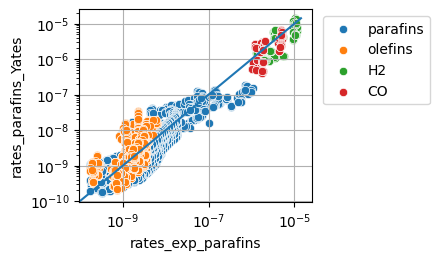

In [47]:
fig, axs = plt.subplots(figsize = (3, 2.5))

max_xy = -rates_H2_CO.min().min()
sns.scatterplot(data = rates_plot_parafins, x = 'rates_exp_parafins', y = 'rates_parafins_Yates',
               ax = axs, 
               label = 'parafins',
               )
sns.scatterplot(data = rates_plot_olefins, x = 'rates_exp_olefins', y = 'rates_olefins_Yates',
               ax = axs, label = 'olefins')
sns.scatterplot(data = -rates_H2_CO, x = 'rates_exp_H2', y = 'rates_Yates_H2',
               ax = axs, label = 'H2')
sns.scatterplot(data = -rates_H2_CO, x = 'rates_exp_CO', y = 'rates_Yates_CO',
               ax = axs, label = 'CO')
plt.yscale('log')
plt.xscale('log')
plt.plot((0, max_xy), (0, max_xy))
plt.grid('both')
plt.legend(bbox_to_anchor=(1.02, 1))

from solve_ODEs import solve_ODEs

model_names = [
    # 'PowerLaw', 
    'Yates', 
    # 'Botes', 'Ojeda', 'Mousavi', 'PowerLaw2'
]

for model in model_names:
    kinetic_data = solve_ODEs(kinetic_data, model, params_dict[model])

kinetic_data.to_pickle('kinetic_data.pkl')

kinetic_data = pd.read_pickle('kinetic_data.pkl')

F_out_Yates_parafins = kinetic_data[[f'F_{component}_out_model_Yates' for component in parafins]]
F_out_Yates_olefins = kinetic_data[[f'F_{component}_out_model_Yates' for component in olefins]]

F_out_Yates_parafins.columns = Fj_out_HCs_parafins.columns
F_out_Yates_olefins.columns = Fj_out_HCs_olefins.columns

kinetic_data.columns

fig, ax = plt.subplots(figsize = (3,2.5))
max_xy = kinetic_data['F_H2_s_mol_s'].max()
sns.scatterplot(data = kinetic_data, x = 'F_H2_s_mol_s', y = 'F_H2_out_model_Yates', ax = ax, label = r'$\mathrm{H_2}$')
sns.scatterplot(data = kinetic_data, x = 'F_CO_s_mol_s', y = 'F_CO_out_model_Yates', ax = ax, label = 'CO')
plt.plot((0, max_xy), (0, max_xy))
plt.grid('both')

fig, ax = plt.subplots(figsize = (3,2.5))
max_xy = kinetic_data['$m_{liq,out}$ (g/s)'].max()
sns.scatterplot(data = kinetic_data, x = '$m_{liq,out}$ (g/s)', y = 'm_liq_out_model_Yates')
plt.plot((0, max_xy), (0, max_xy))
plt.grid('both')

F_out_Yates_parafins.melt()

F_plot_parafins = pd.concat((F_out_Yates_parafins.melt(value_name = 'F_out_Yates_parafins'), 
           Fj_out_HCs_parafins.melt(value_name = 'Fj_out_HCs_parafins').drop(columns='variable')), axis = 'columns')

F_plot_olefins = pd.concat((F_out_Yates_olefins.melt(value_name = 'F_out_Yates_olefins'), 
           Fj_out_HCs_olefins.melt(value_name = 'Fj_out_HCs_olefins').drop(columns='variable')), axis = 'columns')

fig, axs = plt.subplots(figsize = (3, 2.5))
max_xy = F_plot_parafins.Fj_out_HCs_parafins.max()
sns.scatterplot(data = F_plot_parafins, x = 'Fj_out_HCs_parafins', y = 'F_out_Yates_parafins',
               ax = axs, label = 'parafins')
sns.scatterplot(data = F_plot_olefins, x = 'F_out_Yates_olefins', y = 'Fj_out_HCs_olefins',
               ax = axs, label = 'olefins')
# plt.xscale('log')
# plt.yscale('log')
plt.plot((0, max_xy), (0, max_xy))
plt.grid('both')